# Feature Engineering Notebook
This notebook includes a comprehensive pipeline for data preprocessing and feature engineering on the dataset at `data/processed/main/merged.csv`.

### Step 1. Load the merged dataset

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Resolve paths robustly whether kernel CWD is project root or Notebooks/
project_root = Path.cwd()
if not (project_root / "data").exists():
    project_root = project_root.parent
input_path = project_root / "data" / "processed" / "main" / "merged.csv"
output_path = project_root / "data" / "processed" / "main" / "feature_engineered.csv"

# Load merged dataset
df = pd.read_csv(input_path, low_memory=False)
print(f"Loaded shape: {df.shape}")
print(f"Input path: {input_path}")
df.head(3)

### Step 2: Handle Missing Values

In [ ]:
df_clean = df.copy()

# Drop highly missing columns
missing_ratio = df_clean.isna().mean()
too_missing_cols = missing_ratio[missing_ratio > 0.50].index.tolist()
df_clean = df_clean.drop(columns=too_missing_cols, errors="ignore")

# Impute missing values
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_clean.select_dtypes(include=["object", "category", "string"]).columns.tolist()

# Fill numeric columns with median
for col in numeric_cols:
    if df_clean[col].isna().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Fill categorical columns with mode
for col in categorical_cols:
    if df_clean[col].isna().any():
        mode_series = df_clean[col].mode(dropna=True)
        if not mode_series.empty:
            df_clean[col] = df_clean[col].fillna(mode_series.iloc[0])

Dropped columns with >50% missing values: ['cohost_ids', 'cohost_names', 'instant_book']
Dropped columns count: 3
Shape after Step 1: (47813, 62)


### Step 3: Drop Leakage and Useless Features

In [ ]:
# Drop non-informative and leakage columns
drop_always = [
    'listing_id', 'cover_photo_url', 'host_id', 'host_name', 'listing_name', 'cohost_names', 'currency',
    'city', 'country', 'country_code'
]
drop_l90d = [col for col in df_clean.columns if col.startswith('l90d_')]


# Drop native currency duplicates
drop_native = [col for col in df_clean.columns if col.endswith('_native')] 

# Drop potential leakage columns
drop_leakage = ['ttm_revpar', 'ttm_occupancy', 'ttm_adjusted_occupancy', 'ttm_adjusted_revpar']

# Combine all and drop
cols_to_drop = drop_always + drop_l90d + drop_native + drop_leakage
cols_to_drop = [col for col in cols_to_drop if col in df_clean.columns] 

original_shape = df_clean.shape
df_clean = df_clean.drop(columns=cols_to_drop)

# Drop duplicate columns
df_clean = df_clean.drop_duplicates()

Original shape : (47813, 62)
After dropping : (47813, 34)
Dropped 32 columns

Remaining columns:
['listing_type', 'room_type', 'photos_count', 'superhost', 'latitude', 'longitude', 'guests', 'bedrooms', 'beds', 'baths', 'registration', 'amenities', 'professional_management', 'min_nights', 'cancellation_policy', 'cleaning_fee', 'extra_guest_fee', 'num_reviews', 'rating_overall', 'rating_accuracy', 'rating_checkin', 'rating_cleanliness', 'rating_communication', 'rating_location', 'rating_value', 'ttm_revenue', 'ttm_avg_rate', 'ttm_reserved_days', 'ttm_blocked_days', 'ttm_available_days', 'ttm_total_days', 'geographic_zone', 'distance_from_city_center', 'city_population']


### Step 4: Create Derived Features

In [ ]:
import sys
project_root = Path.cwd()
if not (project_root / "scripts").exists():
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
from scripts.data.main.amenties_utility import create_amenity_features
from scripts.data.main.listing_type_utils import categorize_listing

# Create amenities_count and one-hot encode amenities, then drop original amenities column
amenity_features = create_amenity_features(df_clean['amenities'])
df_clean = pd.concat([df_clean, amenity_features], axis=1)
df_clean = df_clean.drop(columns=['amenities'], errors="ignore")

# Take average of all rating columns to create avg_rating, then drop original rating columns
rating_cols = [
    c for c in df_clean.columns
    if c.startswith("rating_")
]
if rating_cols:
    df_clean["avg_rating"] = df_clean[rating_cols].mean(axis=1, skipna=True)
    df_clean = df_clean.drop(columns=rating_cols, errors="ignore")

# Normalize listing_type into broader categories
df_clean['listing_type'] = df_clean['listing_type'].apply(categorize_listing)

# Add a luxury score based on amenities and listing type
luxury_bonus = 8 
df_clean.loc[df_clean['listing_type'] == 'luxury_unique', 'luxury_score'] += luxury_bonus

Created amenities_count and avg_rating. Shape after Step 2: (47813, 46)


### Step 5: Convert Boolean-like Values to 0/1

In [ ]:
# Convert boolean-like columns to integers
bool_like_map = {
    "TRUE": 1, "FALSE": 0,
    "true": 1, "false": 0,
    "True": 1, "False": 0,
    True: 1, False: 0,
    "YES": 1, "NO": 0,
    "yes": 1, "no": 0,
    "Y": 1, "N": 0
}

for col in df_clean.columns:
    if df_clean[col].dtype == bool:
        df_clean[col] = df_clean[col].astype(int)
        continue

    if df_clean[col].dtype == object:
        s = df_clean[col].dropna().astype(str).str.strip()
        if len(s) == 0:
            continue
        unique_vals = set(s.unique())
        if unique_vals.issubset({"TRUE", "FALSE", "true", "false", "True", "False", "YES", "NO", "yes", "no", "Y", "N"}):
            df_clean[col] = df_clean[col].map(bool_like_map)

Boolean conversion complete. Shape after Step 4: (47813, 46)


### Step 6: Remove Outliers (After Imputation)

In [ ]:
import sys
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
from scripts.data.main.outlier_analysis import analyze_outliers_iqr

# Analyze outliers in non-binary numeric features using IQR method
outlier_df = analyze_outliers_iqr(df_clean)
display(outlier_df)

Analyzed 31 non-binary numeric features.


,feature,lower_bound,upper_bound,outlier_count,outlier_pct
0,city_population,-1.123992e+06,1.923988e+06,5843,12.22
1,min_nights,-2.000000e+00,6.000000e+00,5652,11.82
2,ttm_revenue,-2.510400e+04,4.966400e+04,3876,8.11
3,distance_from_city_center,-3.464509e+00,8.132934e+00,3686,7.71
4,cleaning_fee,-7.200000e+01,1.200000e+02,3584,7.50
5,bedrooms,-5.000000e-01,3.500000e+00,3426,7.17
6,rarity_score,-1.933413e-03,6.365216e-03,3339,6.98
7,num_reviews,-1.965000e+02,3.995000e+02,3333,6.97
8,ttm_blocked_days,-9.450000e+01,1.575000e+02,3308,6.92
9,ttm_avg_rate,-1.307000e+02,3.525000e+02,3277,6.85


In [ ]:
import numpy as np
import pandas as pd

# Remove rows with invalid negative values in key numeric features
invalid_conditions = (
    (df_clean["min_nights"] < 0) |
    (df_clean["distance_from_city_center"] < 0) |
    (df_clean["cleaning_fee"] < 0) |
    (df_clean["bedrooms"] < 0) |
    (df_clean["beds"] < 0) |
    (df_clean["baths"] < 0) |
    (df_clean["guests"] < 0) |
    (df_clean["num_reviews"] < 0) |
    (df_clean["photos_count"] < 0)
)
df_clean = df_clean[~invalid_conditions].copy()

# Define features and their IQR multipliers for outlier detection
outlier_features = {
    "distance_from_city_center": 3.0,
    "min_nights": 3.0,
    "cleaning_fee": 3.0,
    "bedrooms": 3.0,
    "beds": 3.0,
    "baths": 3.0,
    "num_reviews": 3.0,
    "photos_count": 3.0,
    "ttm_blocked_days": 3.0,
}

# Initialize a boolean Series to keep track of rows to retain
rows_to_keep = pd.Series([True] * len(df_clean), index=df_clean.index)

# Apply IQR-based outlier detection and mark rows to remove
for col, iqr_mult in outlier_features.items():
    if col not in df_clean.columns:
        continue
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    if IQR == 0:
        continue

    lower_bound = Q1 - iqr_mult * IQR
    upper_bound = Q3 + iqr_mult * IQR

    outlier_mask = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
    outlier_count = outlier_mask.sum()
    outlier_pct = 100 * outlier_count / len(df_clean)
    rows_to_keep = rows_to_keep & ~outlier_mask

df_before = len(df_clean)
df_clean = df_clean[rows_to_keep].copy()
rows_removed = df_before - len(df_clean)
rows_pct_removed = 100 * rows_removed / df_before
print(df_clean["ttm_avg_rate"].describe())

Removed 0 invalid rows (negative values).

FEATURE OUTLIER ROW REMOVAL (IQR-Based, Target Preserved)
  distance_from_city_center: 1410 outliers (2.95%) | bounds: [-7.81, 12.48]
  min_nights: 4477 outliers (9.36%) | bounds: [-5.00, 9.00]
  cleaning_fee: 1516 outliers (3.17%) | bounds: [-144.00, 192.00]
  bedrooms: 639 outliers (1.34%) | bounds: [-2.00, 5.00]
  beds: 602 outliers (1.26%) | bounds: [-5.00, 9.00]
  baths: 547 outliers (1.14%) | bounds: [-2.00, 5.00]
  num_reviews: 929 outliers (1.94%) | bounds: [-420.00, 623.00]
  photos_count: 606 outliers (1.27%) | bounds: [-47.00, 100.00]
  ttm_blocked_days: 577 outliers (1.21%) | bounds: [-189.00, 252.00]

Removed 9728 rows (20.35%) with feature anomalies.
Remaining rows: 38085

Target distribution retained (no explicit ttm_avg_rate cutoff):
count    38085.000000
mean       124.362106
std        123.029867
min          8.600000
25%         48.200000
50%         89.200000
75%        159.500000
max       3525.000000
Name: ttm_avg_rate, d

In [ ]:
outlier_df = analyze_outliers_iqr(df_clean)
display(outlier_df)

Analyzed 31 non-binary numeric features.


,feature,lower_bound,upper_bound,outlier_count,outlier_pct
0,baths,2.500000e-01,2.250000e+00,8931,23.45
1,city_population,-1.283540e+06,2.192200e+06,4026,10.57
2,ttm_revenue,-2.334700e+04,4.650900e+04,2887,7.58
3,ttm_blocked_days,-8.100000e+01,1.350000e+02,2741,7.20
4,rarity_score,-1.822463e-03,6.154332e-03,2558,6.72
5,distance_from_city_center,-3.232850e+00,7.766469e+00,2277,5.98
6,family_count,-1.500000e+00,2.500000e+00,2161,5.67
7,num_reviews,-1.990000e+02,4.090000e+02,2078,5.46
8,ttm_avg_rate,-1.187500e+02,3.264500e+02,2045,5.37
9,cleaning_fee,-6.900000e+01,1.150000e+02,2024,5.31



STEP 5 IMPACT ON TARGET DISTRIBUTION


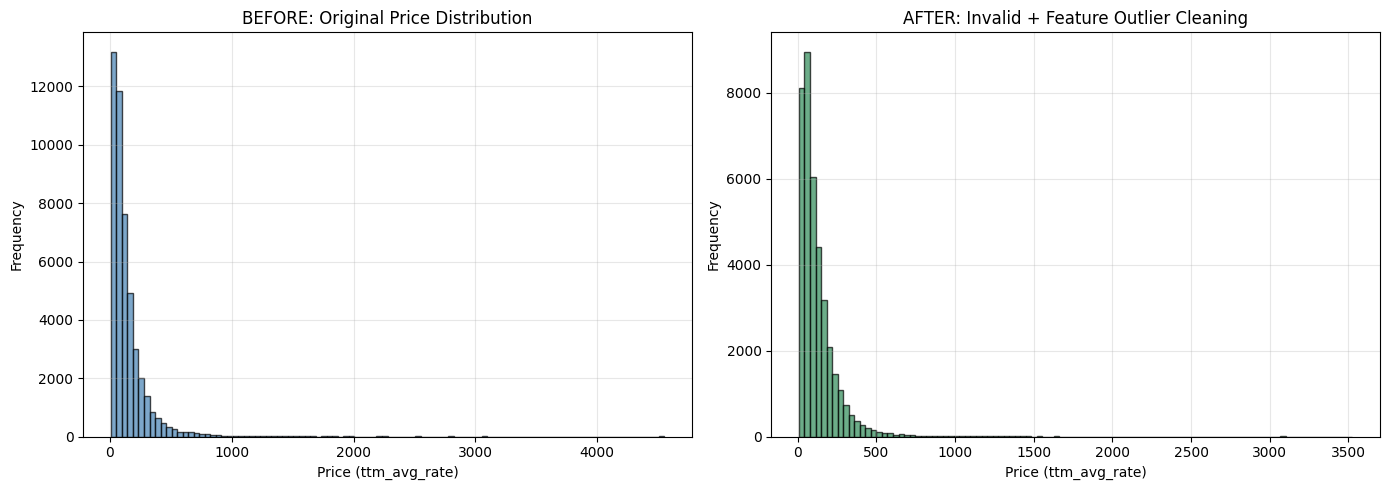


Data quality summary:
  Rows removed: 9728
  Rows remaining: 38085
  Price range: $8.60 - $3525.00
  Price mean: $124.36
  Price std: $123.03
  Listings in top 5% price band (>= $335.20): 1907

No explicit high-price hard cutoff applied.


In [ ]:
# Visualize target distribution before vs after Step 5 (without target hard cutoff)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original data
axes[0].hist(df['ttm_avg_rate'], bins=100, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('Price (ttm_avg_rate)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('BEFORE: Original Price Distribution')
axes[0].grid(True, alpha=0.3)

# After cleaning
axes[1].hist(df_clean['ttm_avg_rate'], bins=100, alpha=0.7, color='seagreen', edgecolor='black')
axes[1].set_xlabel('Price (ttm_avg_rate)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('AFTER: Invalid + Feature Outlier Cleaning')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Step 7: Encoding Categorical Features

In [ ]:
# Use the cleaned dataframe before one-hot encoding
source_df = df_clean if "df_clean" in globals() else df_clean

# Identify categorical columns for encoding
categorical_cols = source_df.select_dtypes(include=["object", "category", "string"]).columns.tolist()
unique_counts = source_df[categorical_cols].nunique(dropna=False).sort_values(ascending=False)

df_encoded = df_clean.copy()

# Ordinal Encoding — cancellation_policy
cancellation_order = {
    'Full Refundable Until Check-in': 0,
    'Full Refundable Until 24 Hours Before Check-in': 1,
    'Full Refundable Until 72 Hours Before Check-in': 2,
    'Refundable': 3,
    'Flexible': 4,
    'Moderate': 5,
    'Limited': 6,
    'Firm': 7,
    'Strict': 8,
    'Non-refundable': 9,
    'Super Strict 30 Days': 10,
    'Super Strict 60 Days': 11
}
df_encoded['cancellation_policy'] = df_encoded['cancellation_policy'].str.strip().map(cancellation_order)

# One-Hot Encoding — geographic_zone, room_type
df_encoded = pd.get_dummies(df_encoded, columns=['listing_type', 'room_type', 'geographic_zone'])

# Verify
print(df_encoded.shape)
print(df_encoded.dtypes[df_encoded.dtypes == 'object']) 

Categorical columns found: 4
['listing_type', 'room_type', 'cancellation_policy', 'geographic_zone']

Unique values per categorical column:
cancellation_policy: 12
listing_type: 11
geographic_zone: 6
room_type: 4


### Step 8: Applying Transformations

In [ ]:
import numpy as np

# Log-transform skewed numeric features to reduce outlier impact 
log_cols = [
    'ttm_avg_rate',
    'ttm_revenue',
    'num_reviews', 
    'distance_from_city_center',
]

for col in log_cols:
    if col in df_encoded.columns:
        df_encoded[col] = np.log1p(df_encoded[col]) 

✓ Applied log transformation to: ['ttm_avg_rate', 'ttm_revenue', 'num_reviews', 'distance_from_city_center']


### Step 9: Correlation Analysis
- Drop highly correlated features to reduce redundancy
- Plot a correlation heatmap on the top-variance numeric features in the final engineered dataset for readability.

In [ ]:
corr_matrix = df_encoded.select_dtypes(include=[np.number]).corr().abs()

# Find all pairs with correlation > 0.7
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [(col, row) for col in upper.columns 
             for row in upper.index 
             if upper[col][row] > 0.7]

print(high_corr)

[('bedrooms', 'guests'), ('beds', 'guests'), ('ttm_reserved_days', 'ttm_revenue'), ('ttm_available_days', 'ttm_revenue'), ('ttm_available_days', 'ttm_reserved_days')]


In [ ]:
# Drop highly correlated features
drop_correlated = ['ttm_revpar', 'ttm_available_days', 'ttm_reserved_days']
df_encoded = df_encoded.drop(columns=drop_correlated, errors='ignore')

(37293, 62)


### Step 10. Save the feature engineered dataset

In [ ]:
df_encoded.to_csv(output_path, index=False)
print(f"Final engineered shape: {df_encoded.shape}")
df_encoded.head(3)

Final engineered shape: (37293, 62)
Saved engineered data to: c:\Users\RUSHIKESH\Desktop\Airbnb Project\data\processed\main\feature_engineered.csv


,photos_count,superhost,latitude,longitude,guests,bedrooms,beds,baths,registration,professional_management,...,room_type_entire_home,room_type_hotel_room,room_type_private_room,room_type_shared_room,geographic_zone_Africa,geographic_zone_Asia Pacific,geographic_zone_Europe,geographic_zone_Latin America,geographic_zone_Middle East,geographic_zone_Northern America
0,34.0,1,5.5733,-0.1960,2.0,1.0,1.0,1.5,0,0,...,True,False,False,False,True,False,False,False,False,False
1,14.0,0,5.5860,-0.1673,2.0,2.0,2.0,1.0,0,0,...,True,False,False,False,True,False,False,False,False,False
2,10.0,1,5.5610,-0.1856,2.0,1.0,1.0,1.0,0,0,...,True,False,False,False,True,False,False,False,False,False
